In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
latent_dim = 100
epochs = 10

print(device)

cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Dataset loaded")

Dataset loaded


In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(100,256,7,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,1,3,1,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        return self.model(x)
        

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,3,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256*4*4,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [7]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)


Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3

In [8]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Loss and optimizers ready")

Loss and optimizers ready


In [9]:
real_images, _ = next(iter(loader))

real_images = real_images.to(device)

noise = torch.randn(batch_size,100,1,1).to(device)

fake_images = generator(noise)

print("Real:", real_images.shape)
print("Fake:", fake_images.shape)

Real: torch.Size([128, 1, 28, 28])
Fake: torch.Size([128, 1, 28, 28])


In [10]:
G_losses = []
D_losses = []

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(loader):

        real_images = real_images.to(device)
        batch = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch, 1).to(device)
        fake_labels = torch.zeros(batch, 1).to(device)


        # -----------------
        # Train Discriminator
        # -----------------

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(real_images)
        d_real_loss = criterion(real_output, real_labels)


        # Fake images
        noise = torch.randn(batch,100,1,1).to(device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        d_fake_loss = criterion(fake_output, fake_labels)


        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_D.step()


        # -----------------
        # Train Generator
        # -----------------

        optimizer_G.zero_grad()

        output = discriminator(fake_images)
        g_loss = criterion(output, real_labels)

        g_loss.backward()
        optimizer_G.step()


    G_losses.append(g_loss.item())
    D_losses.append(d_loss.item())
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/10] D Loss: 0.6678 G Loss: 1.1229
Epoch [2/10] D Loss: 0.8029 G Loss: 1.1027
Epoch [3/10] D Loss: 0.6458 G Loss: 1.3399
Epoch [4/10] D Loss: 0.4223 G Loss: 2.7880
Epoch [5/10] D Loss: 0.4909 G Loss: 2.8870
Epoch [6/10] D Loss: 0.7303 G Loss: 2.7776
Epoch [7/10] D Loss: 0.5373 G Loss: 2.2413
Epoch [8/10] D Loss: 0.7006 G Loss: 0.9691
Epoch [9/10] D Loss: 0.7936 G Loss: 1.1286
Epoch [10/10] D Loss: 0.2891 G Loss: 3.3438


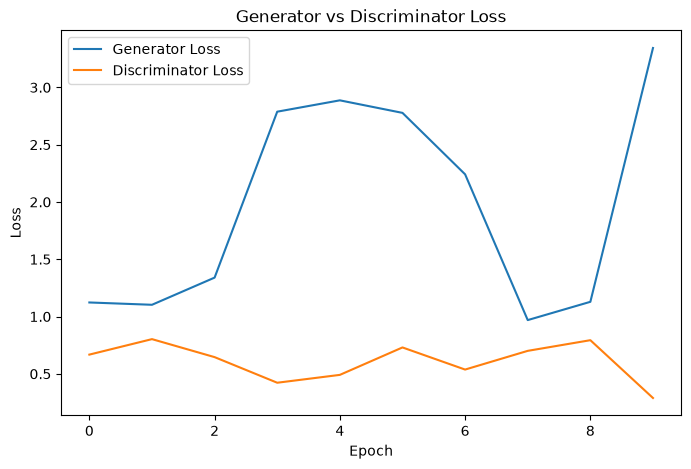

In [11]:
plt.figure(figsize=(8,5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator vs Discriminator Loss")

plt.legend()
plt.show()

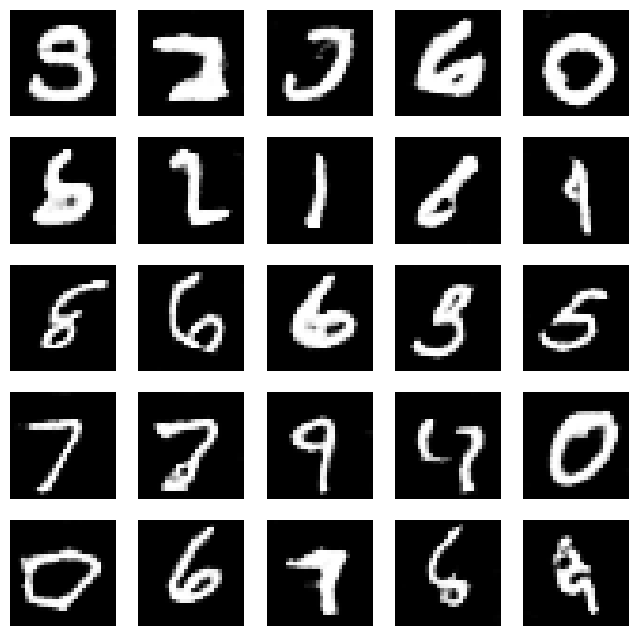

In [13]:
with torch.no_grad():
    noise = torch.randn(25, latent_dim, 1, 1).to(device)
    generated_images = generator(noise).cpu()

generated_images = (generated_images + 1) / 2

fig, axes = plt.subplots(5,5, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i][0], cmap="gray")
    ax.axis("off")

plt.show()

In [14]:
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

print("Models saved")

Models saved


## Architecture Explanation

The Generator takes a random noise vector of size 100 as input and uses fully connected layers to generate 28×28 grayscale images. It uses ReLU activation and Batch Normalization to improve training stability. The final layer uses Tanh activation to produce normalized images.

The Discriminator is a binary classifier that takes an image as input and predicts whether it is real or generated. It uses Linear layers with LeakyReLU activation and a Sigmoid output layer. During training, the Generator learns to create realistic images while the Discriminator learns to distinguish fake images from real MNIST images.